# 🌳 Decision Tree Regression — Recursive Splitting for Continuous Targets

The recursive splitting mechanics were already derived for classification in [Classification / Decision Tree](../../Classification/04_Decision_Tree_Classifier/) (Gini/entropy, the `SimpleTreeNode` recursive builder). Regression trees use the identical recursive splitting algorithm with one change: the splitting criterion becomes variance/MSE reduction instead of Gini/entropy, and each leaf predicts the *mean* of its training points instead of a majority class. This produces a genuinely different-looking model than every other method in this category: a staircase of constant predictions, not a smooth curve.

📖 Full mathematical explanation (MSE-reduction splitting criterion, cost-complexity pruning, tree instability): [README.md](README.md)


## 1. Setup & Datasets

A synthetic piecewise curve (distinct pieces with a jump, ideal for seeing the staircase structure clearly) plus the Diabetes dataset for this category's running comparison.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_piecewise(x):
    return np.where(x < -2, -2, np.where(x < 1, x ** 2, np.where(x < 3, 4 - x, 1) ))

n_samples = 150
X_1d = np.sort(np.random.uniform(-5, 5, n_samples))
y_1d = true_piecewise(X_1d) + np.random.normal(0, 0.3, n_samples)

X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(X_1d.reshape(-1, 1), y_1d, test_size=0.25, random_state=42)
print(f"Piecewise dataset: {n_samples} points, train={len(X_1d_train)}, test={len(X_1d_test)}")


Piecewise dataset: 150 points, train=112, test=38


In [3]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)
print(f"Diabetes: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")


Diabetes: 10 features, train=(331, 10), test=(111, 10)


## 2. The Splitting Criterion — Variance (MSE) Reduction

For a candidate split dividing a node's points into left/right subsets:

$$\Delta = \text{Var}(\text{parent}) - \left(\frac{n_L}{n}\text{Var}(\text{left}) + \frac{n_R}{n}\text{Var}(\text{right})\right)$$

The tree greedily picks the feature and threshold maximizing $\Delta$ at each node -- the direct regression analogue of Gini/entropy reduction in classification.


In [4]:
def variance_reduction(y_parent, y_left, y_right):
    n = len(y_parent)
    var_parent = np.var(y_parent)
    weighted_child_var = (len(y_left) / n) * np.var(y_left) + (len(y_right) / n) * np.var(y_right)
    return var_parent - weighted_child_var

def best_split_1d(X, y):
    best_gain, best_threshold = -np.inf, None
    sorted_x = np.sort(np.unique(X.ravel()))
    for i in range(len(sorted_x) - 1):
        threshold = (sorted_x[i] + sorted_x[i + 1]) / 2
        left_mask = X.ravel() <= threshold
        if left_mask.sum() == 0 or (~left_mask).sum() == 0:
            continue
        gain = variance_reduction(y, y[left_mask], y[~left_mask])
        if gain > best_gain:
            best_gain, best_threshold = gain, threshold
    return best_threshold, best_gain

manual_threshold, manual_gain = best_split_1d(X_1d_train, y_1d_train)
print(f"Manual best first split: threshold={manual_threshold:.3f}, variance reduction={manual_gain:.3f}")


Manual best first split: threshold=-2.018, variance reduction=2.599


In [5]:
tree_depth1 = DecisionTreeRegressor(max_depth=1).fit(X_1d_train, y_1d_train)
sklearn_threshold = tree_depth1.tree_.threshold[0]
print(f"sklearn's depth-1 tree split threshold: {sklearn_threshold:.3f}")
print(f"Match with manual search? {np.isclose(manual_threshold, sklearn_threshold, atol=0.05)}")


sklearn's depth-1 tree split threshold: -2.018
Match with manual search? True


In [6]:
true_breakpoints = [-2, 1, 3]
print(f"True piecewise function's breakpoints: {true_breakpoints}")
print(f"First split threshold found: {sklearn_threshold:.3f}")
closest_breakpoint = min(true_breakpoints, key=lambda b: abs(b - sklearn_threshold))
print(f"-> Closest true breakpoint: {closest_breakpoint} (distance={abs(closest_breakpoint - sklearn_threshold):.3f}) -- a single split naturally gravitates toward the largest variance-reducing structural change in the data, even without knowing the true function.")


True piecewise function's breakpoints: [-2, 1, 3]
First split threshold found: -2.018
-> Closest true breakpoint: -2 (distance=0.018) -- a single split naturally gravitates toward the largest variance-reducing structural change in the data, even without knowing the true function.


## 3. The Staircase — How a Regression Tree Actually Predicts

Every leaf predicts the mean of the training points that landed in it -- a constant. The overall prediction function is therefore a step function, not a smooth curve, regardless of how deep the tree grows.


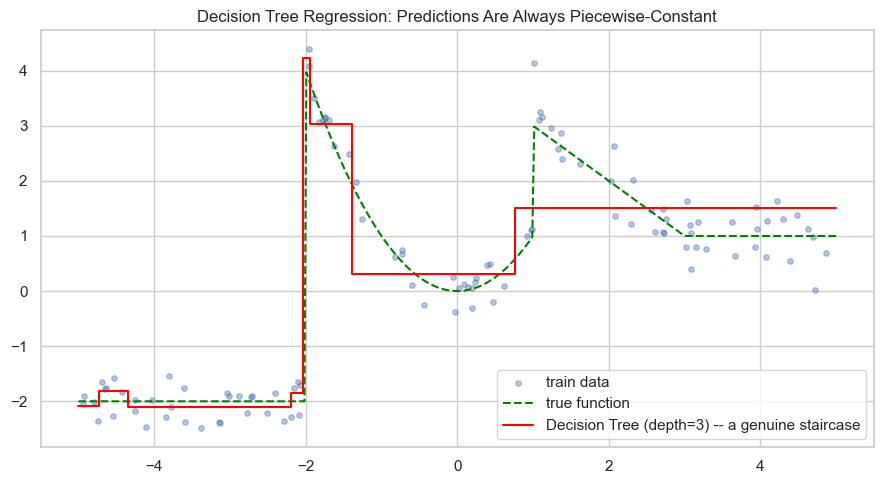

In [7]:
x_plot = np.linspace(-5, 5, 400).reshape(-1, 1)
tree_shallow = DecisionTreeRegressor(max_depth=3).fit(X_1d_train, y_1d_train)
y_tree_plot = tree_shallow.predict(x_plot)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_1d_train, y_1d_train, alpha=0.4, s=15, label="train data")
ax.plot(x_plot, true_piecewise(x_plot), color="green", linestyle="--", label="true function")
ax.step(x_plot.ravel(), y_tree_plot, color="red", label="Decision Tree (depth=3) -- a genuine staircase")
ax.set_title("Decision Tree Regression: Predictions Are Always Piecewise-Constant")
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
n_leaves = tree_shallow.get_n_leaves()
print(f"Depth-3 tree has {n_leaves} leaves -- exactly {n_leaves} distinct constant prediction values across the entire input range.")
print(f"Unique predicted values: {np.round(np.unique(y_tree_plot), 3)}")


Depth-3 tree has 8 leaves -- exactly 8 distinct constant prediction values across the entire input range.
Unique predicted values: [-2.104 -2.082 -1.843 -1.812  0.315  1.512  3.025  4.233]


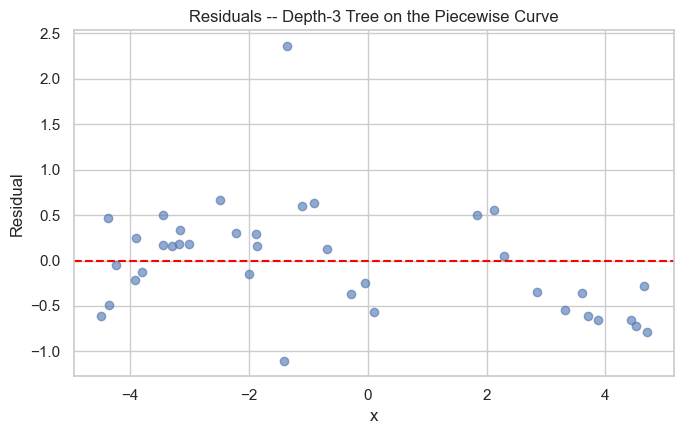

Residual std: 0.602 -- notice residuals cluster in patterns within each leaf's x-range, since every point in a leaf shares the exact same prediction regardless of its true value's variation within that range.


In [9]:
residuals_1d_tree = y_1d_test - tree_shallow.predict(X_1d_test)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_1d_test, residuals_1d_tree, alpha=0.6)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("x"); ax.set_ylabel("Residual")
ax.set_title("Residuals -- Depth-3 Tree on the Piecewise Curve")
plt.tight_layout()
plt.show()
print(f"Residual std: {residuals_1d_tree.std():.3f} -- notice residuals cluster in patterns within each leaf's x-range, since every point in a leaf shares the exact same prediction regardless of its true value's variation within that range.")


## 4. Visualizing the Tree Structure Itself

Unlike every method so far, a shallow tree's decision logic can be read directly as a sequence of if/else rules.


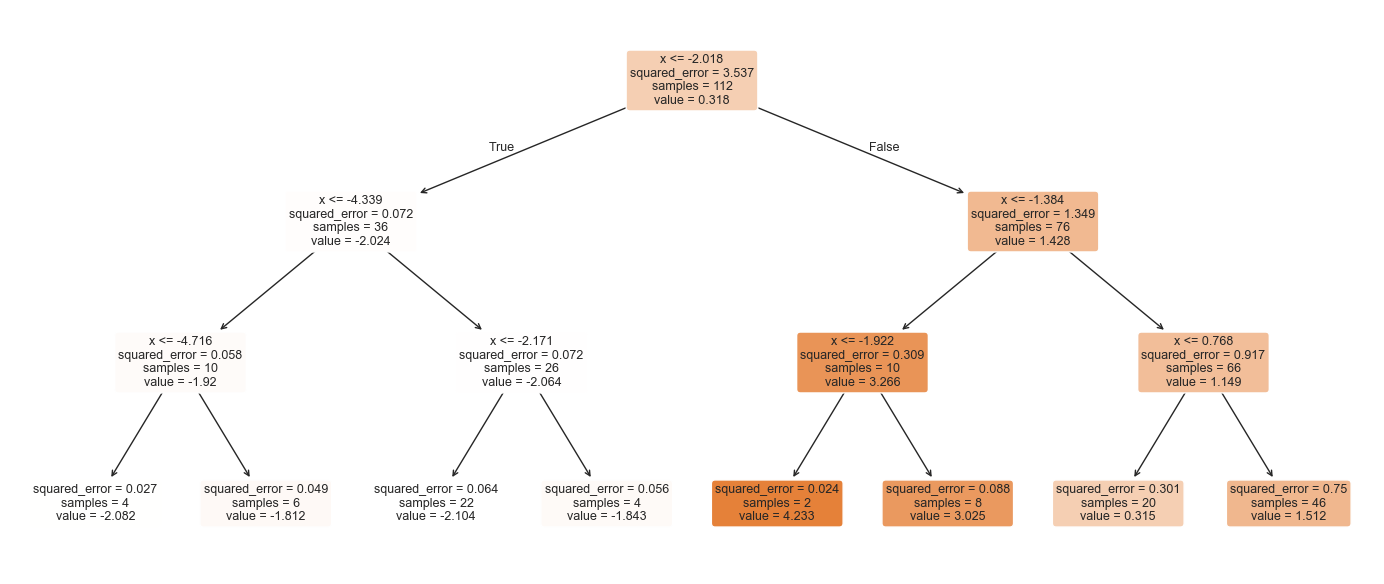

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(tree_shallow, feature_names=["x"], filled=True, rounded=True, fontsize=9, ax=ax)
plt.tight_layout()
plt.show()


## 5. The Effect of `max_depth` — Underfitting to Overfitting

A depth-1 tree can only make one split (extreme underfitting). An unbounded tree can keep splitting until every leaf has a single point (extreme overfitting -- zero training error, but memorization, not learning).


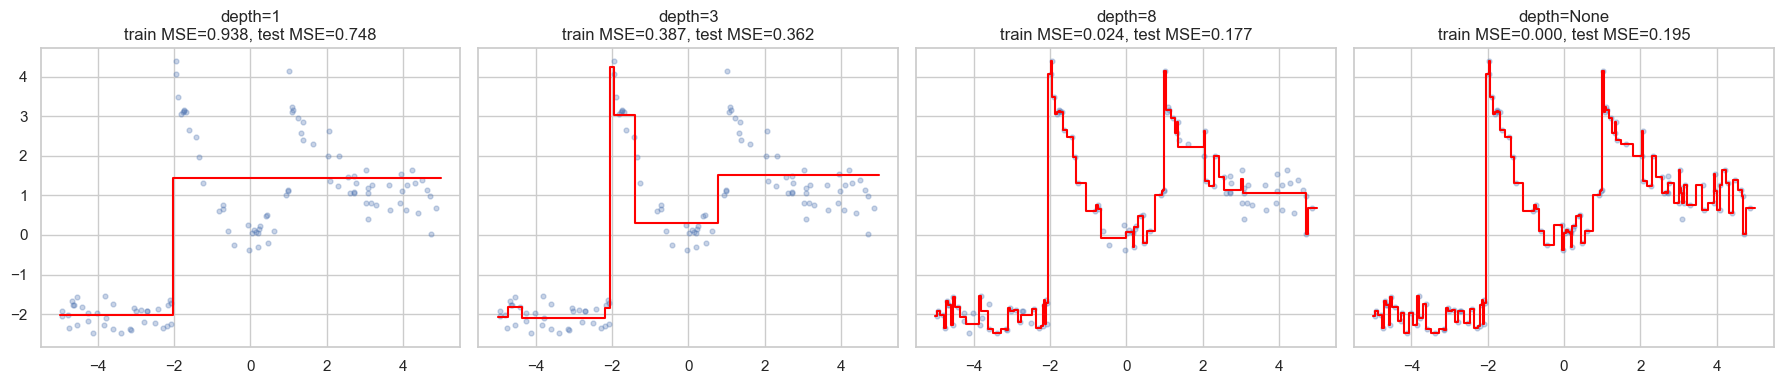

In [11]:
depths_to_show = [1, 3, 8, None]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
depth_results = {}
for ax, depth in zip(axes, depths_to_show):
    model = DecisionTreeRegressor(max_depth=depth).fit(X_1d_train, y_1d_train)
    y_plot = model.predict(x_plot)
    train_mse = mean_squared_error(y_1d_train, model.predict(X_1d_train))
    test_mse = mean_squared_error(y_1d_test, model.predict(X_1d_test))
    depth_results[str(depth)] = (train_mse, test_mse, model.get_n_leaves())
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=12)
    ax.step(x_plot.ravel(), y_plot, color="red")
    ax.set_title(f"depth={depth}\ntrain MSE={train_mse:.3f}, test MSE={test_mse:.3f}")
plt.tight_layout()
plt.show()


In [12]:
depth_df = pd.DataFrame([
    {"max_depth": d, "train_MSE": round(tr, 4), "test_MSE": round(te, 4), "n_leaves": nl}
    for d, (tr, te, nl) in depth_results.items()
])
depth_df


,max_depth,train_MSE,test_MSE,n_leaves
0,1,0.9383,0.7481,2
1,3,0.3868,0.3622,8
2,8,0.0243,0.1771,72
3,None,0.0000,0.1950,112


In [13]:
unbounded_row = depth_df[depth_df["max_depth"] == "None"].iloc[0]
print(f"Unbounded tree: {unbounded_row['n_leaves']} leaves, train MSE={unbounded_row['train_MSE']}, test MSE={unbounded_row['test_MSE']}")
print(f"-> Train MSE near zero with {unbounded_row['n_leaves']} leaves for {len(X_1d_train)} training points confirms the tree is memorizing individual points, not learning the underlying pattern -- classic overfitting.")


Unbounded tree: 112 leaves, train MSE=0.0, test MSE=0.195
-> Train MSE near zero with 112 leaves for 112 training points confirms the tree is memorizing individual points, not learning the underlying pattern -- classic overfitting.


## 6. Pre-Pruning — `min_samples_leaf` and `min_samples_split`

Rather than limiting depth directly, these parameters stop splitting once a node would produce leaves that are "too small" -- a different, often more robust way to control complexity.


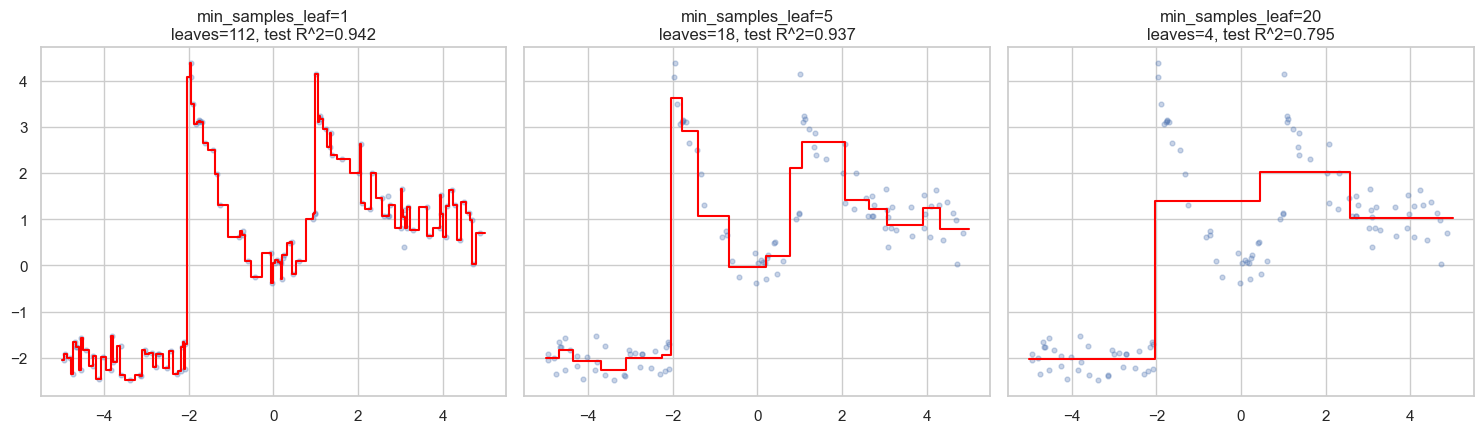

In [14]:
min_leaf_values = [1, 5, 20]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
leaf_results = {}
for ax, min_leaf in zip(axes, min_leaf_values):
    model = DecisionTreeRegressor(min_samples_leaf=min_leaf).fit(X_1d_train, y_1d_train)
    test_r2 = r2_score(y_1d_test, model.predict(X_1d_test))
    leaf_results[min_leaf] = (model.get_n_leaves(), test_r2)
    ax.scatter(X_1d_train, y_1d_train, alpha=0.3, s=12)
    ax.step(x_plot.ravel(), model.predict(x_plot), color="red")
    ax.set_title(f"min_samples_leaf={min_leaf}\nleaves={model.get_n_leaves()}, test R^2={test_r2:.3f}")
plt.tight_layout()
plt.show()


In [15]:
for min_leaf, (n_leaves, test_r2) in leaf_results.items():
    print(f"min_samples_leaf={min_leaf:<4}: {n_leaves} leaves, test R^2={test_r2:.4f}")


min_samples_leaf=1   : 112 leaves, test R^2=0.9417
min_samples_leaf=5   : 18 leaves, test R^2=0.9365
min_samples_leaf=20  : 4 leaves, test R^2=0.7952


## 7. Post-Pruning — Cost-Complexity Pruning (`ccp_alpha`)

Rather than stopping growth early, cost-complexity pruning grows a full tree first, then removes the subtrees whose removal costs the least in training error per leaf saved. `alpha` controls how aggressively to prune.


In [16]:
full_tree = DecisionTreeRegressor().fit(X_1d_train, y_1d_train)
path = full_tree.cost_complexity_pruning_path(X_1d_train, y_1d_train)
ccp_alphas = path.ccp_alphas

pruned_trees = [DecisionTreeRegressor(ccp_alpha=a).fit(X_1d_train, y_1d_train) for a in ccp_alphas]
train_scores_ccp = [r2_score(y_1d_train, t.predict(X_1d_train)) for t in pruned_trees]
test_scores_ccp = [r2_score(y_1d_test, t.predict(X_1d_test)) for t in pruned_trees]
n_leaves_ccp = [t.get_n_leaves() for t in pruned_trees]
print(f"Pruning path has {len(ccp_alphas)} candidate alpha values, from {ccp_alphas[0]:.5f} to {ccp_alphas[-1]:.5f}")


Pruning path has 90 candidate alpha values, from 0.00000 to 2.59853


In [17]:
sample_idx = np.linspace(0, len(ccp_alphas) - 1, min(8, len(ccp_alphas))).astype(int)
ccp_sample_df = pd.DataFrame({
    "ccp_alpha": np.round(np.array(ccp_alphas)[sample_idx], 5),
    "n_leaves": np.array(n_leaves_ccp)[sample_idx],
    "train_R2": np.round(np.array(train_scores_ccp)[sample_idx], 4),
    "test_R2": np.round(np.array(test_scores_ccp)[sample_idx], 4),
})
ccp_sample_df


,ccp_alpha,n_leaves,train_R2,test_R2
0,0.00000,112,1.0000,0.9417
1,0.00001,99,1.0000,0.9418
2,0.00007,85,0.9998,0.9437
3,0.00035,70,0.9989,0.9463
4,0.00062,54,0.9967,0.9484
5,0.00112,38,0.9926,0.9515
6,0.00269,14,0.9802,0.9628
7,2.59853,1,0.0000,-0.0188


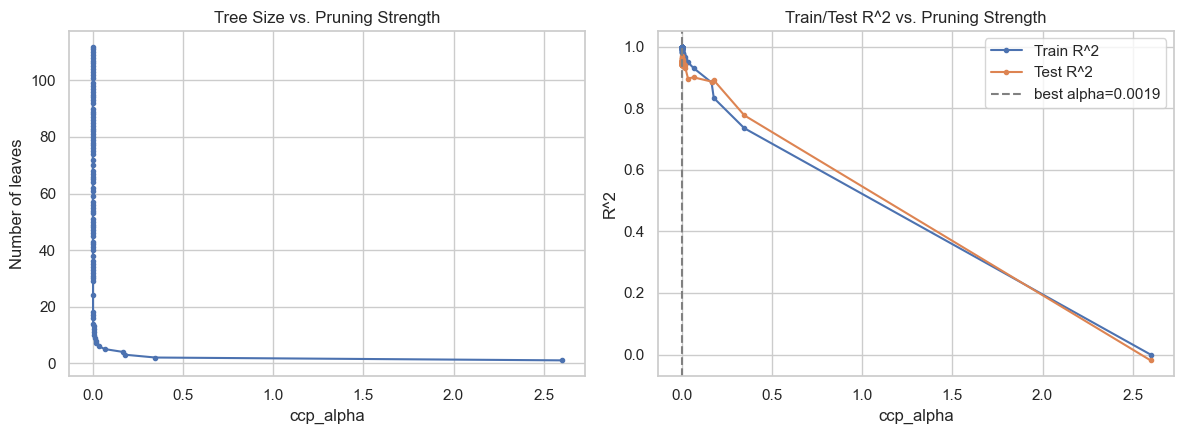

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(ccp_alphas, n_leaves_ccp, marker=".")
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("Number of leaves"); axes[0].set_title("Tree Size vs. Pruning Strength")

axes[1].plot(ccp_alphas, train_scores_ccp, marker=".", label="Train R^2")
axes[1].plot(ccp_alphas, test_scores_ccp, marker=".", label="Test R^2")
best_alpha_idx = np.argmax(test_scores_ccp)
axes[1].axvline(ccp_alphas[best_alpha_idx], color="gray", linestyle="--", label=f"best alpha={ccp_alphas[best_alpha_idx]:.4f}")
axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("R^2"); axes[1].set_title("Train/Test R^2 vs. Pruning Strength")
axes[1].legend()
plt.tight_layout()
plt.show()


In [19]:
print(f"Best ccp_alpha by test R^2: {ccp_alphas[best_alpha_idx]:.5f}")
print(f"Resulting tree: {n_leaves_ccp[best_alpha_idx]} leaves, test R^2={test_scores_ccp[best_alpha_idx]:.4f}")
print(f"Compare to unpruned tree: {n_leaves_ccp[0]} leaves, test R^2={test_scores_ccp[0]:.4f}")


Best ccp_alpha by test R^2: 0.00192
Resulting tree: 18 leaves, test R^2=0.9705
Compare to unpruned tree: 112 leaves, test R^2=0.9417


## 8. Trees Don't Need Feature Scaling

Every split threshold-compares one feature at a time -- there's no distance calculation or coefficient magnitude for differing feature scales to distort. Verifying this directly rather than just asserting it.


In [20]:
X_2feat_demo = np.column_stack([
    np.random.uniform(0, 5, 150),
    np.random.uniform(0, 5000, 150),
])
y_2feat_demo = 2.0 * X_2feat_demo[:, 0] + 0.003 * X_2feat_demo[:, 1] + np.random.normal(0, 0.5, 150)
X2_train, X2_test, y2_train, y2_test = train_test_split(X_2feat_demo, y_2feat_demo, test_size=0.25, random_state=42)

from sklearn.preprocessing import StandardScaler
tree_unscaled = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X2_train, y2_train)
unscaled_r2 = r2_score(y2_test, tree_unscaled.predict(X2_test))

scaler_2feat = StandardScaler().fit(X2_train)
tree_scaled = DecisionTreeRegressor(max_depth=5, random_state=42).fit(scaler_2feat.transform(X2_train), y2_train)
scaled_r2 = r2_score(y2_test, tree_scaled.predict(scaler_2feat.transform(X2_test)))

print(f"Tree on UNSCALED two-feature data -- test R^2: {unscaled_r2:.4f}")
print(f"Tree on SCALED two-feature data   -- test R^2: {scaled_r2:.4f}")
print(f"Difference: {abs(unscaled_r2 - scaled_r2):.4f} -- {'negligible, as expected: threshold splits are scale-invariant' if abs(unscaled_r2 - scaled_r2) < 0.02 else 'unexpectedly large for a method that should be scale-invariant'}")


Tree on UNSCALED two-feature data -- test R^2: 0.9197
Tree on SCALED two-feature data   -- test R^2: 0.9197
Difference: 0.0000 -- negligible, as expected: threshold splits are scale-invariant


## 9. Feature Importance

Summing the variance reduction each feature contributes across every split where it was used, normalized to sum to 1.


In [21]:
tree_diabetes = DecisionTreeRegressor(max_depth=4, random_state=42).fit(Xd_train, yd_train)
importance_df = pd.DataFrame({
    "feature": Xd.columns,
    "importance": np.round(tree_diabetes.feature_importances_, 4)
}).sort_values("importance", ascending=False)
importance_df


,feature,importance
2,bmi,0.6132
8,s5,0.1642
9,s6,0.0683
3,bp,0.0534
4,s1,0.0338
7,s4,0.0283
5,s2,0.0208
0,age,0.0181
1,sex,0.0000
6,s3,0.0000


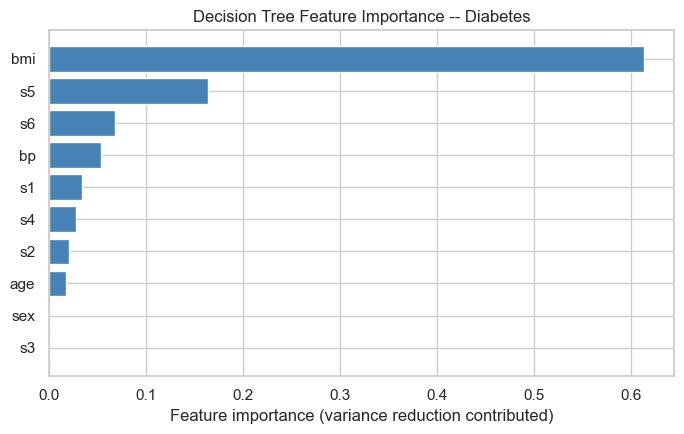

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
ax.set_xlabel("Feature importance (variance reduction contributed)")
ax.set_title("Decision Tree Feature Importance -- Diabetes")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Tree Instability — a Motivation for the Next Topic

A single-tree model can change structurally with small perturbations to the training data -- a property that directly motivates Random Forest (next topic): average many unstable trees to get one stable prediction.


In [23]:
instability_results = []
rng = np.random.RandomState(0)
for trial in range(5):
    idx = rng.choice(len(Xd_train), size=len(Xd_train), replace=True)
    tree_trial = DecisionTreeRegressor(max_depth=3, random_state=42).fit(Xd_train.iloc[idx], yd_train.iloc[idx])
    top_feature = Xd.columns[np.argmax(tree_trial.feature_importances_)]
    instability_results.append({"bootstrap_trial": trial, "top_feature": top_feature, "top_feature_importance": round(tree_trial.feature_importances_.max(), 3)})

pd.DataFrame(instability_results)


,bootstrap_trial,top_feature,top_feature_importance
0,0,bmi,0.529
1,1,bmi,0.705
2,2,bmi,0.659
3,3,bmi,0.600
4,4,bmi,0.626


In [24]:
unique_top_features = pd.DataFrame(instability_results)["top_feature"].nunique()
print(f"Across 5 bootstrap resamples of the same training data, the single most important feature changed {unique_top_features} different times.")
if unique_top_features > 1:
    print("-> A single tree's structure is genuinely sensitive to which specific rows happened to be in the training sample -- exactly the instability Random Forest's bagging (next topic) is designed to average away.")
else:
    print("-> The top feature stayed consistent across resamples here, though deeper structural details (thresholds, lower-level splits) still typically vary more than this top-level summary shows.")


Across 5 bootstrap resamples of the same training data, the single most important feature changed 1 different times.
-> The top feature stayed consistent across resamples here, though deeper structural details (thresholds, lower-level splits) still typically vary more than this top-level summary shows.


## 11. Tuning `max_depth`, `min_samples_leaf`, and `ccp_alpha` on Real Data

Joint grid search on Diabetes.


In [25]:
tree_param_grid = {
    "max_depth": [2, 3, 4, 5, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
}
tree_grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), tree_param_grid, cv=5, scoring="r2").fit(Xd_train, yd_train)

print(f"Best params: {tree_grid_search.best_params_}")
print(f"Best CV R^2: {tree_grid_search.best_score_:.4f}")


Best params: {'max_depth': 2, 'min_samples_leaf': 20}
Best CV R^2: 0.3389


In [26]:
import time
t0 = time.perf_counter(); DecisionTreeRegressor(random_state=42).fit(Xd_train, yd_train); tree_fit_time = time.perf_counter() - t0
t0 = time.perf_counter(); KNeighborsRegressor(n_neighbors=17).fit(Xd_train, yd_train).predict(Xd_test); knn_time = time.perf_counter() - t0
print(f"Decision Tree fit time: {tree_fit_time*1000:.2f} ms")
print(f"KNN fit+predict time:   {knn_time*1000:.2f} ms")
print("-> Trees pay a one-time fit cost (like every parametric method) and then predict in O(depth) per query -- fast at both fit and predict time, unlike KNN's per-prediction search cost measured in the previous topic.")


Decision Tree fit time: 2.29 ms
KNN fit+predict time:   4.58 ms
-> Trees pay a one-time fit cost (like every parametric method) and then predict in O(depth) per query -- fast at both fit and predict time, unlike KNN's per-prediction search cost measured in the previous topic.


In [27]:
tree_best_test_r2 = r2_score(yd_test, tree_grid_search.predict(Xd_test))
tree_best_train_r2 = r2_score(yd_train, tree_grid_search.predict(Xd_train))
print(f"Train R^2: {tree_best_train_r2:.4f}")
print(f"Test R^2:  {tree_best_test_r2:.4f}")
print(f"Gap: {tree_best_train_r2 - tree_best_test_r2:.4f}  ({'small' if tree_best_train_r2 - tree_best_test_r2 < 0.15 else 'notable'})")


Train R^2: 0.4381
Test R^2:  0.3588
Gap: 0.0793  (small)


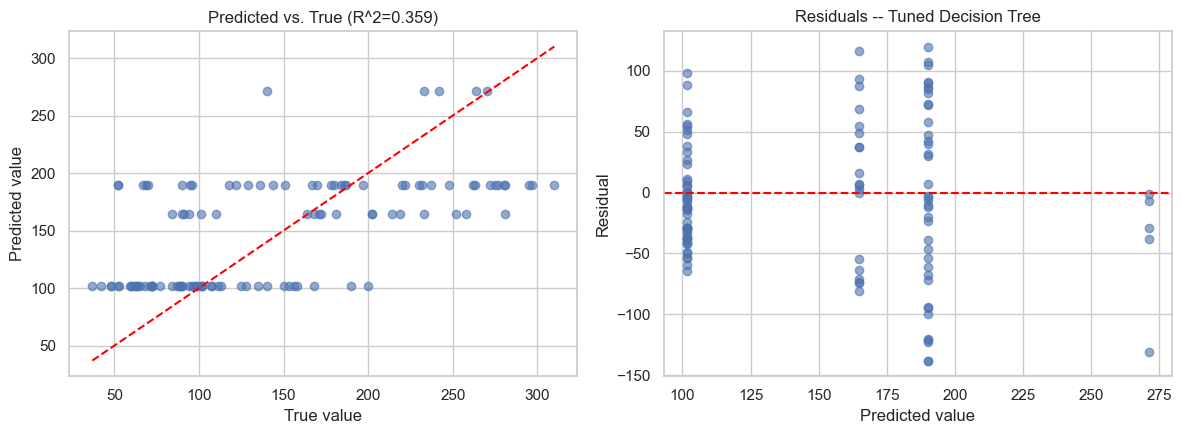

In [28]:
tree_pred_diabetes = tree_grid_search.predict(Xd_test)
residuals_tree = yd_test - tree_pred_diabetes

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yd_test, tree_pred_diabetes, alpha=0.6)
lims = [min(yd_test.min(), tree_pred_diabetes.min()), max(yd_test.max(), tree_pred_diabetes.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("True value"); axes[0].set_ylabel("Predicted value"); axes[0].set_title(f"Predicted vs. True (R^2={tree_best_test_r2:.3f})")

axes[1].scatter(tree_pred_diabetes, residuals_tree, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals -- Tuned Decision Tree")
plt.tight_layout()
plt.show()


## 12. Comparison Against Every Prior Regression Method in This Category

Continuing this category's running comparison table with Decision Tree Regression added.


In [29]:
scaler_final = StandardScaler().fit(Xd_train)
Xd_train_scaled, Xd_test_scaled = scaler_final.transform(Xd_train), scaler_final.transform(Xd_test)

ridge_diabetes = Ridge(alpha=10.0).fit(Xd_train_scaled, yd_train)
linear_diabetes = LinearRegression().fit(Xd_train_scaled, yd_train)
svr_diabetes = SVR(kernel="rbf", C=100, epsilon=1.0, gamma=0.01).fit(Xd_train_scaled, yd_train)
knn_diabetes = KNeighborsRegressor(n_neighbors=17, weights="distance").fit(Xd_train_scaled, yd_train)

category_comparison = pd.DataFrame([
    {"Model": "Linear Regression (topic 01)", "Test R2": round(r2_score(yd_test, linear_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "Ridge (topic 03)", "Test R2": round(r2_score(yd_test, ridge_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "SVR, RBF, tuned (topic 04)", "Test R2": round(r2_score(yd_test, svr_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "KNN Regression, tuned (topic 05)", "Test R2": round(r2_score(yd_test, knn_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "Decision Tree, tuned (this topic)", "Test R2": round(tree_best_test_r2, 4)},
]).set_index("Model")
category_comparison


,Test R2
Model,
Linear Regression (topic 01),0.4849
Ridge (topic 03),0.4881
"SVR, RBF, tuned (topic 04)",0.4925
"KNN Regression, tuned (topic 05)",0.4708
"Decision Tree, tuned (this topic)",0.3588


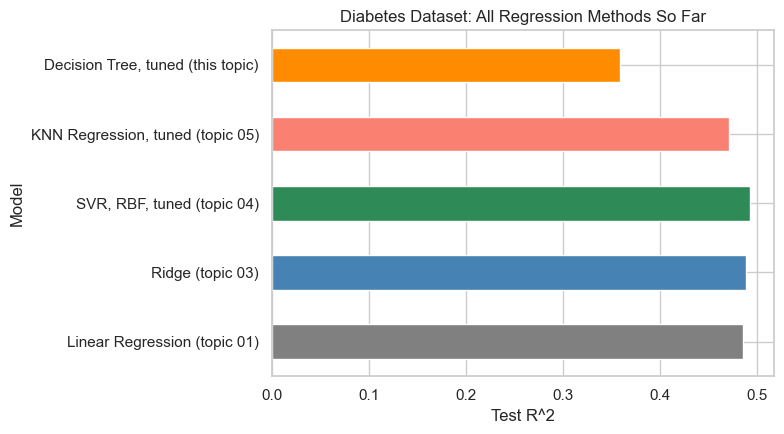

Best so far: SVR, RBF, tuned (topic 04) (0.4925)
Worst so far: Decision Tree, tuned (this topic) (0.3588)
-> A single tree underperforming every other method here is itself expected -- it's the exact motivation for Random Forest and Gradient Boosting, both coming up next in this category.


In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))
category_comparison["Test R2"].plot(kind="barh", ax=ax, color=["gray", "steelblue", "seagreen", "salmon", "darkorange"])
ax.set_xlabel("Test R^2")
ax.set_title("Diabetes Dataset: All Regression Methods So Far")
plt.tight_layout()
plt.show()

best_model = category_comparison["Test R2"].idxmax()
worst_model = category_comparison["Test R2"].idxmin()
print(f"Best so far: {best_model} ({category_comparison['Test R2'].max():.4f})")
print(f"Worst so far: {worst_model} ({category_comparison['Test R2'].min():.4f})")
if "Decision Tree" in worst_model:
    print("-> A single tree underperforming every other method here is itself expected -- it's the exact motivation for Random Forest and Gradient Boosting, both coming up next in this category.")


## 13. Summary

A single decision tree's core strength -- fully interpretable if/else logic, no scaling required, natural handling of non-linear and interaction effects -- comes with a real cost this notebook measured directly: instability under resampling (Section 10) and, on this specific dataset, weaker predictive performance than every other method tried so far in this category (Section 12). Both findings point toward the same fix, which is exactly what the next two topics build: combining many trees into an ensemble.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
